<a href="https://colab.research.google.com/github/KshitijMaurya0898/PROJECT--CATS-and-DOGS-IMAGE-CLASSIFICATIONS-/blob/main/projectcnn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# INTRODUCTION

Cat & Dog Classification using Convolutional Neural Network in Python



---
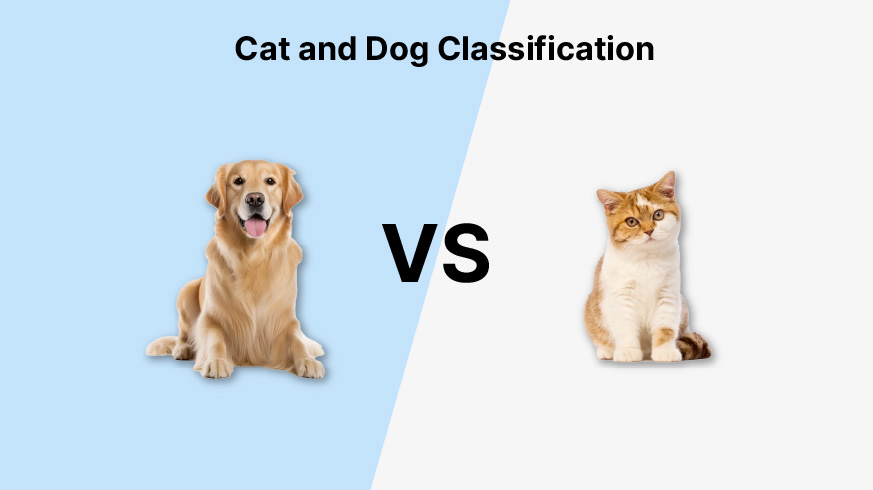



---

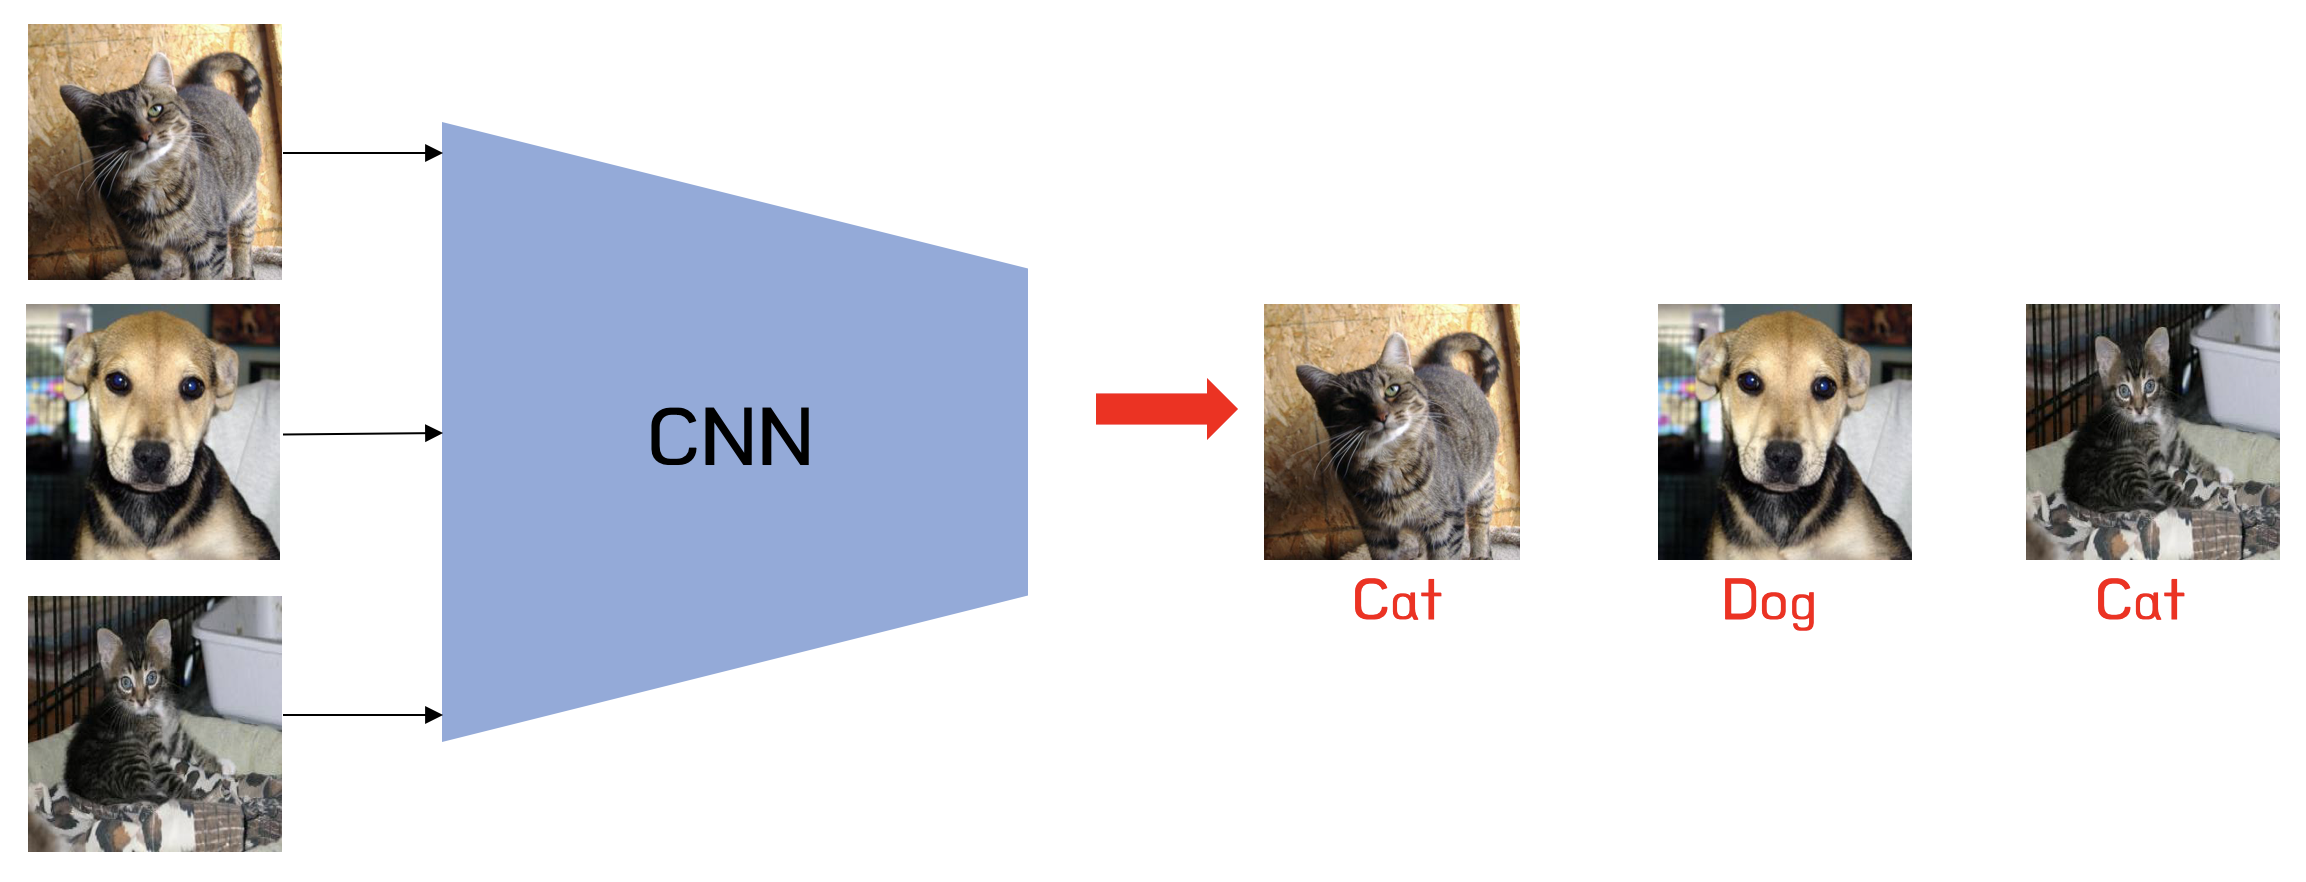



# 1. Importing Libraries
We will import the required libraries such as Numpy, Pandas, Matplotlib, Scikit-learn, OpenCV, TensorFlow.



In [ ]:
import matplotlib.pyplot as plt
import tensorflow as tf
import pandas as pd
import numpy as np

import warnings
warnings.filterwarnings('ignore')

from tensorflow import keras
from keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Activation, Dropout, Flatten, Dense
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.utils import image_dataset_from_directory
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img
from tensorflow.keras.preprocessing import image_dataset_from_directory

import os
import matplotlib.image as mpimg

# 2. Importing Dataset
We will be using Kaggle dataset for this which is in the format of a zip file containing 2 folders : Cat and Dog. Further each folder contains 12500 images of respective animals. So to import and unzip the file and we can run the below code.

The ZipFile module extracts dataset files from the zip archive.
Extracted data is stored in the 'dog-vs-cat-classification' folder.

In [ ]:
!unzip dogsvscats.zip

In [1]:
from zipfile import ZipFile

data_path = '/content/drive/MyDrive/Colab Notebooks/dog-vs-cat.zip'

with ZipFile(data_path, 'r') as zip:
    zip.extractall()
    print('The data set has been extracted.')

The data set has been extracted.


# 3. Visualizating the Data
We will try to understand and visualize some images which have been provided to us to build the classifier for each class. We extract image paths and loads them using Matplotlib and plot grid visualization using subplot().




---
---

👉 fig = plt.gcf() gets the current figure.

👉 fig.set_size_inches(16, 16) sets the figure size.


👉 cat_dir and dog_dir define paths to the cat and dog image directories.


👉  cat_names and dog_names list the image files in each directory.


👉  cat_images and dog_images select images based on pic_index.


👉  plt.subplot(4, 4, i+1) creates a 4x4 grid for images.

👉sp.axis('Off') hides the axis.
mpimg.imread(img_path) reads each image and plt.imshow(img) displays it.


 👉 plt.show() shows the grid of images.




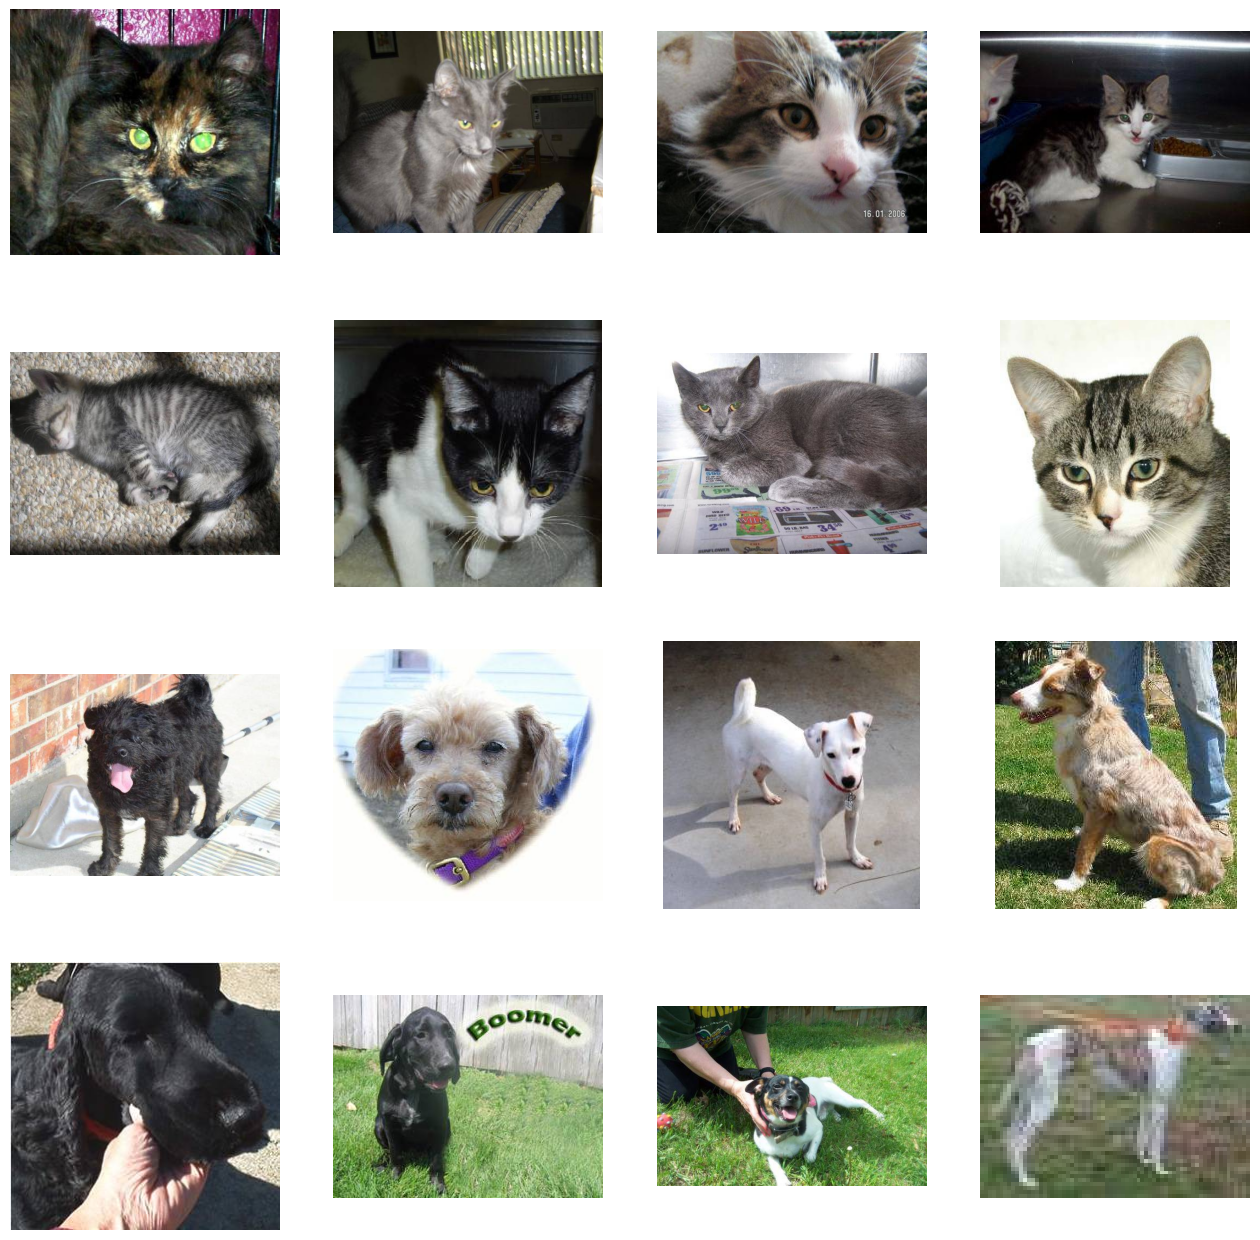

In [7]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os
import numpy as np
from tensorflow.keras.preprocessing import image

fig = plt.gcf()
fig.set_size_inches(16, 16)

cat_dir = os.path.join('/content/dogcat/train/cats')
dog_dir = os.path.join('/content/dogcat/train/dogs')
cat_names = os.listdir(cat_dir)
dog_names = os.listdir(dog_dir)

pic_index = 210

cat_images = [os.path.join(cat_dir, fname)
              for fname in cat_names[pic_index-8:pic_index]]
dog_images = [os.path.join(dog_dir, fname)
              for fname in dog_names[pic_index-8:pic_index]]

for i, img_path in enumerate(cat_images + dog_images):
    sp = plt.subplot(4, 4, i+1)
    sp.axis('Off')

    img = mpimg.imread(img_path)
    plt.imshow(img)

plt.show()

# 4. Splitting Dataset

We split the dataset into training and validation sets.



*   image_dataset_from_directory: is used for data augmentation and scaling images.

*   The dataset is split into 90% training and 10% validation.


*   target_size=(200, 200): Resizes images to 200x200 pixels.

*   batch_size=32: Defines the number of images per batch.






In [11]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img
from tensorflow.keras.utils import image_dataset_from_directory

base_dir = '/content/dogcat'

train_datagen = image_dataset_from_directory(base_dir,
                                                  image_size=(200,200),
                                                  subset='training',
                                                  seed = 1,
                                                 validation_split=0.1,
                                                  batch_size= 32)
test_datagen = image_dataset_from_directory(base_dir,
                                                  image_size=(200,200),
                                                  subset='validation',
                                                  seed = 1,
                                                 validation_split=0.1,
                                                  batch_size= 32)

Found 45500 files belonging to 3 classes.
Using 40950 files for training.
Found 45500 files belonging to 3 classes.
Using 4550 files for validation.


# 5. Model Architecture

The model will contain the following Layers:



*   Conv2D layers: extract image features like edges, shapes and textures.

* MaxPooling2D: reduces image dimensions while retaining important information.
   

*   BatchNormalization: helps stabilize training and speed up convergence.

* Dropout layers: prevent overfitting.


*   sigmoid activation: outputs a binary classification as Cat or Dog.









In [13]:
import tensorflow as tf
from tensorflow import keras
from keras import layers

model = tf.keras.models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(200, 200, 3)),
    layers.MaxPooling2D(2, 2),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),

    layers.Flatten(),
    layers.Dense(512, activation='relu'),
    layers.BatchNormalization(),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.1),
    layers.BatchNormalization(),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.2),
    layers.BatchNormalization(),
    layers.Dense(1, activation='sigmoid')
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 198, 198, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 99, 99, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 97, 97, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 48, 48, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 46, 46, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 23, 23, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 21, 21, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 10, 10, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6400)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     3,277,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,902,529 (14.89 MB)

 Trainable params: 3,899,457 (14.88 MB)

 Non-trainable params: 3,072 (12.00 KB)

# 6. Model Compilation and Training
Now we will compile and train our model. We used Binary Crossentropy Loss Function for binary classification problems with Adam optimizer.



*   model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy']) compiles the model with binary cross-entropy loss, Adam optimizer and accuracy as the metric.

*   history = model.fit(train_datagen, epochs=10, validation_data=test_datagen) trains the model for 10 epochs using the training data and validates it using the test data.







In [14]:
model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

history = model.fit(train_datagen,
          epochs=10,
          validation_data=test_datagen)

Epoch 1/10
1280/1280 ━━━━━━━━━━━━━━━━━━━━ 79s 52ms/step - accuracy: 0.5257 - loss: 0.4659 - val_accuracy: 0.5389 - val_loss: 0.3322
Epoch 2/10
1280/1280 ━━━━━━━━━━━━━━━━━━━━ 60s 47ms/step - accuracy: 0.5452 - loss: 0.3642 - val_accuracy: 0.5389 - val_loss: 0.3137
Epoch 3/10
1280/1280 ━━━━━━━━━━━━━━━━━━━━ 61s 47ms/step - accuracy: 0.5468 - loss: 0.3551 - val_accuracy: 0.5389 - val_loss: 0.4211
Epoch 4/10
1280/1280 ━━━━━━━━━━━━━━━━━━━━ 61s 48ms/step - accuracy: 0.5463 - loss: 0.3523 - val_accuracy: 0.5389 - val_loss: 0.3797
Epoch 5/10
1280/1280 ━━━━━━━━━━━━━━━━━━━━ 61s 47ms/step - accuracy: 0.5466 - loss: 0.3485 - val_accuracy: 0.5385 - val_loss: 0.3130
Epoch 6/10
1280/1280 ━━━━━━━━━━━━━━━━━━━━ 60s 47ms/step - accuracy: 0.5466 - loss: 0.3479 - val_accuracy: 0.5389 - val_loss: 0.3171
Epoch 7/10
1280/1280 ━━━━━━━━━━━━━━━━━━━━ 65s 51ms/step - accuracy: 0.5464 - loss: 0.3492 - val_accuracy: 0.5389 - val_loss: 0.2958
Epoch 8/10
1280/1280 ━━━━━━━━━━━━━━━━━━━━ 60s 47ms/step - accuracy: 0.5467 -

# 7. Model Evaluation

Let’s visualize the training and validation accuracy with each epoch.



*   history_df = pd.DataFrame(history.history) converts the training history into a DataFrame.

*   history_df.loc[:, ['loss', 'val_loss']].plot() plots the training and validation loss.



*   history_df.loc[:, ['accuracy', 'val_accuracy']].plot() plots the training and validation accuracy.







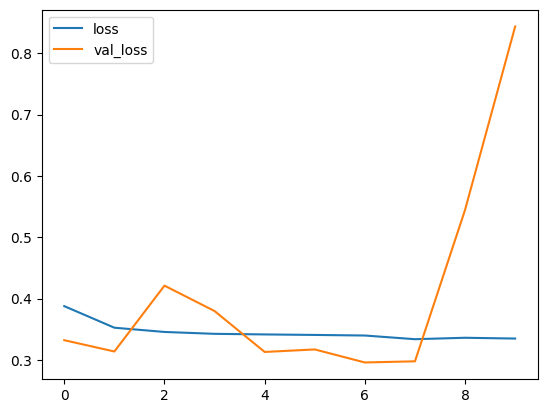

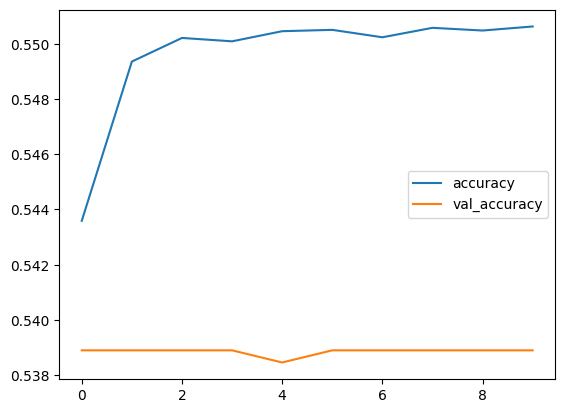

In [16]:
import pandas as pd
import matplotlib.pyplot as plt

history_df = pd.DataFrame(history.history)
history_df.loc[:, ['loss', 'val_loss']].plot()
history_df.loc[:, ['accuracy', 'val_accuracy']].plot()
plt.show()

# 8. Model Testing and Prediction
Let's check the model for random images.



*  img = image.load_img(image_path, target_size=(200, 200)) loads the image and resizes it to 200x200 pixels.

*   plt.imshow(img) displays the image.


*  img = image.img_to_array(img) converts the image to a NumPy array.

*   img = np.expand_dims(img, axis=0) adds an extra dimension for batch processing.


*   img = np.expand_dims(img, axis=0) adds an extra dimension for batch processing.






1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
Dog


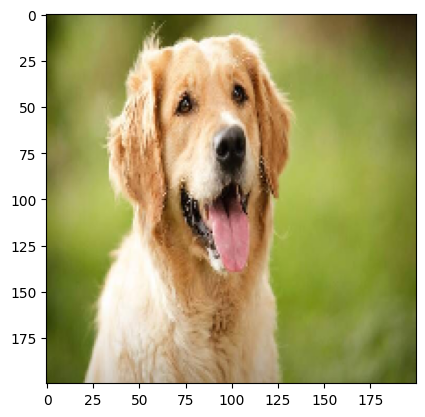

In [27]:
def predict_image(image_path):
    img = image.load_img(image_path, target_size=(200, 200))
    plt.imshow(img)
    img = image.img_to_array(img)
    img = np.expand_dims(img, axis=0)

    result = model.predict(img)
    print("Dog" if result >= 0.5 else "Cat")

predict_image('/content/dog.jpg')